# VAEP 男女足训练数据比较：同一份女足测试集上的 action-value 差异

这个 notebook 是 three_method_comparison-2.ipynb 里 VAEP 部分的单独拆解版。

核心问题和 xG / xT notebook 一样：

> 用男足数据训练出的 VAEP 模型，和用女足数据训练出的 VAEP 模型，当它们被用在同一份女足测试 actions 上时，给出的球员价值和排名有什么差异？

整体流程：

1. 加载男女足 SPADL actions，并把进攻方向统一成从左到右。
2. 在女足比赛层面切出 held-out test games。
3. 用 socceraction 的 VAEP feature functions 生成 action-level features 和 labels。
4. 训练两个模型：men downsampled、women。
5. 在同一批女足 test actions 上预测 scoring/conceding probabilities。
6. 用标准 VAEP formula 计算每个 action 的 VAEP value。
7. 按球员、位置 bucket、action type 分析男足模型和女足模型的差异。

## 0. VAEP 在这里到底评价什么？

xG 主要评价 shot quality；xT 主要评价 pass/dribble 是否把球推进到更危险的位置。

VAEP 更细：它试图评价每一个 action 对未来进球和丢球风险的影响。

在 socceraction 的标准 VAEP 框架里，模型先学习两个概率：

- P(score)：当前 game state 下，控球方接下来若干个 actions 内进球的概率。
- P(concede)：当前 game state 下，控球方接下来若干个 actions 内丢球的概率。

然后 VAEP value 看的是 action 前后这些概率的变化：

- offensive value：这个 action 是否提高了后续进球概率。
- defensive value：这个 action 是否降低了后续丢球概率。
- vaep value = offensive value + defensive value。

原 three-method notebook 里把 VAEP 写得很紧凑。这一版会把 feature generation、model training、prediction、VAEP value、player aggregation 拆开写。

## 1. Imports 和 constants

这里不在 notebook 里安装依赖。依赖应该装在项目 .venv 里。

注意：当前环境是 NumPy 2.x，而 socceraction/pandera 依赖链比较旧，所以保留一小段 NumPy compatibility aliases，作用只是让 socceraction 能正常 import，不属于 VAEP 逻辑。

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Compatibility aliases needed by socceraction/pandera on NumPy 2.x.
if not hasattr(np, "string_"):
    np.string_ = np.bytes_
if not hasattr(np, "float_"):
    np.float_ = np.float64
if not hasattr(np, "complex_"):
    np.complex_ = np.complex128

import pandas as pd
from scipy import stats
from sklearn.ensemble import HistGradientBoostingClassifier
from socceraction.data.statsbomb import StatsBombLoader
import socceraction.spadl as spadl
import socceraction.vaep.features as fs
import socceraction.vaep.labels as lab
from socceraction.vaep import formula as vaep_formula

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=pd.errors.ChainedAssignmentError)

DATA_DIR = Path("data")
CACHE_DIR = Path("vaep_data")
OPEN_DATA_DIR = Path("open-data/data")
DATA_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
ALIGN_ATTACKING_DIRECTION = True

N_PREVIOUS_ACTIONS = 3
VAEP_LABEL_HORIZON = 10
MIN_ACTIONS_PER_PLAYER = 100
MIN_ACTIONS_PER_ACTION_TYPE = 500
MIN_PLAYERS_PER_POSITION_BUCKET = 2

if OPEN_DATA_DIR.exists():
    statsbomb_loader = StatsBombLoader(getter="local", root=str(OPEN_DATA_DIR))
    print(f"using local StatsBomb open data: {OPEN_DATA_DIR}")
else:
    statsbomb_loader = StatsBombLoader(getter="remote", creds={})
    print("using remote StatsBomb open data; first SPADL load can be slow")

print("ready")

using local StatsBomb open data: open-data\data
ready


## 2. Competitions

沿用原 three-method notebook 的比赛范围，保证和 xG / xT 分析的研究对象一致。

In [2]:
WOMEN_COMPETITIONS = [
    {"competition_id": 37, "season_id": 281, "league": "WSL"},
    {"competition_id": 135, "season_id": 281, "league": "Frauen Bundesliga"},
    {"competition_id": 182, "season_id": 281, "league": "Liga F"},
    {"competition_id": 131, "season_id": 281, "league": "Serie A Women"},
    {"competition_id": 49, "season_id": 107, "league": "NWSL"},
]

MEN_COMPETITIONS = [
    {"competition_id": 11, "season_id": 27, "league": "La Liga"},
    {"competition_id": 2, "season_id": 27, "league": "Premier League"},
    {"competition_id": 12, "season_id": 27, "league": "Serie A"},
    {"competition_id": 7, "season_id": 27, "league": "Ligue 1"},
]

## 3. 加载 SPADL actions

VAEP 需要完整 action sequence，而不是只看 shots 或 moves。因此这里和 xT 一样使用 SPADL actions。

重要：加载后会把所有球队的进攻方向统一成从左到右，也就是进攻方向为 x 增大。这样 start/end location features 才是相对于控球方进攻方向的。

cache 文件和 xT notebook 共用：

- vaep_data/women_spadl_ltr.parquet
- vaep_data/men2015_spadl_ltr.parquet
- vaep_data/women_pos.parquet

In [3]:
def add_spadl_names_if_needed(actions):
    """Ensure numeric SPADL ids also have readable *_name columns."""
    required_name_columns = {"type_name", "result_name", "bodypart_name"}
    if required_name_columns.issubset(actions.columns):
        return actions
    return spadl.add_names(actions)


def make_events_compatible_with_socceraction(events):
    """Return an events copy that socceraction can convert under pandas/NumPy 2.x."""
    events = events.copy()
    for column in events.columns:
        if pd.api.types.is_string_dtype(events[column].dtype):
            events[column] = events[column].astype(object)
    return events


def load_spadl_actions(competitions, cache_tag):
    """Load SPADL actions and player positions for a list of competitions."""
    direction_suffix = "ltr" if ALIGN_ATTACKING_DIRECTION else "home_perspective"
    actions_cache = CACHE_DIR / f"{cache_tag}_spadl_{direction_suffix}.parquet"
    positions_cache = CACHE_DIR / f"{cache_tag}_pos.parquet"

    if actions_cache.exists() and positions_cache.exists():
        print(f"[cache] {cache_tag} SPADL actions")
        actions = pd.read_parquet(actions_cache)
        positions = pd.read_parquet(positions_cache)
        return add_spadl_names_if_needed(actions), positions

    action_frames = []
    position_frames = []

    for competition in competitions:
        league = competition["league"]
        try:
            games = statsbomb_loader.games(
                competition_id=competition["competition_id"],
                season_id=competition["season_id"],
            )
        except Exception as error:
            print("  !", league, error)
            continue

        print(f"[load] {league}: {len(games)} games")
        for game_index, (_, game) in enumerate(games.iterrows(), start=1):
            try:
                events = statsbomb_loader.events(game.game_id)
                events = make_events_compatible_with_socceraction(events)
                actions = spadl.statsbomb.convert_to_actions(
                    events,
                    home_team_id=game.home_team_id,
                )
                if ALIGN_ATTACKING_DIRECTION:
                    actions = spadl.play_left_to_right(actions, home_team_id=game.home_team_id)
                actions["league"] = league
                action_frames.append(actions)

                if "position_name" in events.columns:
                    position_frames.append(events[["player_id", "position_name"]].dropna())

                if game_index % 25 == 0 or game_index == len(games):
                    print(f"    converted {game_index}/{len(games)} games")
            except Exception as error:
                print("  ! skipped game", game.game_id, error)

    if not action_frames:
        raise RuntimeError(f"No actions loaded for {cache_tag}.")

    actions = pd.concat(action_frames, ignore_index=True)
    positions = (
        pd.concat(position_frames, ignore_index=True)
        if position_frames
        else pd.DataFrame(columns=["player_id", "position_name"])
    )

    actions.to_parquet(actions_cache, index=False)
    positions.to_parquet(positions_cache, index=False)
    print(f"[cache] wrote {cache_tag}: {len(actions):,} actions")
    return add_spadl_names_if_needed(actions), positions


women_actions, women_positions = load_spadl_actions(WOMEN_COMPETITIONS, "women")
men_actions, _ = load_spadl_actions(MEN_COMPETITIONS, "men2015")

print(f"women actions: {len(women_actions):,}")
print(f"men actions:   {len(men_actions):,}")

[cache] women SPADL actions
[cache] men2015 SPADL actions
women actions: 1,505,094
men actions:   3,039,003


## 4. 共享女足 test games、位置表和门将过滤

和 xG / xT 一样，最终比较必须发生在同一批 held-out 女足比赛上。

训练 VAEP 模型时不删门将，因为门将动作是 possession sequence 的一部分。最终做球员排名比较时过滤门将。

In [4]:
random_generator = np.random.default_rng(RANDOM_SEED)
women_game_ids = np.sort(women_actions["game_id"].unique())

WOMEN_TEST_GAMES = set(
    random_generator.choice(
        women_game_ids,
        size=int(len(women_game_ids) * 0.30),
        replace=False,
    )
)

women_train_actions = women_actions[~women_actions.game_id.isin(WOMEN_TEST_GAMES)].copy()
women_test_actions = women_actions[women_actions.game_id.isin(WOMEN_TEST_GAMES)].copy()


def normalize_player_id_series(player_ids):
    """Convert player ids from different loaders/caches to one nullable integer key."""
    return pd.to_numeric(player_ids, errors="coerce").astype("Int64")


women_positions = women_positions.copy()
if len(women_positions):
    women_positions["player_id_key"] = normalize_player_id_series(women_positions["player_id"])
    position_map = (
        women_positions.dropna(subset=["player_id_key"])
        .groupby("player_id_key")["position_name"]
        .agg(lambda positions: positions.value_counts().index[0])
        .to_dict()
    )
else:
    position_map = {}


def primary_position_from_key(player_id_key):
    if pd.isna(player_id_key):
        return "Unknown"
    return position_map.get(int(player_id_key), "Unknown")


def is_goalkeeper_key(player_id_key):
    return "Goalkeeper" in str(primary_position_from_key(player_id_key))


def bucket_position(position_name):
    """Map granular StatsBomb positions to broad tactical buckets."""
    position_name = str(position_name)
    if "Goalkeeper" in position_name:
        return "Goalkeeper"
    if "Center Back" in position_name:
        return "Center Back"
    if "Wing Back" in position_name or position_name in {"Left Back", "Right Back"}:
        return "Fullback / Wing Back"
    if "Defensive Midfield" in position_name:
        return "Defensive Midfield"
    if "Center Midfield" in position_name:
        return "Central Midfield"
    if "Attacking Midfield" in position_name:
        return "Attacking Midfield"
    if position_name in {"Left Midfield", "Right Midfield", "Left Wing", "Right Wing"}:
        return "Wide Midfielder / Winger"
    if "Center Forward" in position_name or position_name == "Striker":
        return "Forward"
    return "Other / Unknown"


print("women test games:", len(WOMEN_TEST_GAMES), "of", len(women_game_ids))
print("women train actions:", f"{len(women_train_actions):,}")
print("women test actions:", f"{len(women_test_actions):,}")
print("positions mapped:", len(position_map))
print("goalkeepers:", sum("Goalkeeper" in str(position) for position in position_map.values()))

women test games: 231 of 771
women train actions: 1,058,678
women test actions: 446,416
positions mapped: 1533
goalkeepers: 138


## 5. VAEP features 和 labels

这里使用 socceraction.vaep.features 生成 action-level feature matrix，用 socceraction.vaep.labels 生成 scores / concedes labels。

注意这里有两个不同的窗口，不能混在一起：

- feature window：`N_PREVIOUS_ACTIONS = 3`，每一行 feature 会看当前 action 和之前几个 actions。
- label horizon：`VAEP_LABEL_HORIZON = 10`，label 表示当前 action 之后 10 个 actions 内控球方是否会进球/丢球。

所以每一行对应一个 action 的 game state；模型学习的是：在这个 game state 下，未来 10 个 actions 内控球方是否会进球、是否会丢球。

In [5]:
VAEP_FEATURE_FUNCTIONS = [
    fs.actiontype_onehot,
    fs.result_onehot,
    fs.bodypart_onehot,
    fs.startlocation,
    fs.endlocation,
    fs.movement,
    fs.space_delta,
    fs.startpolar,
    fs.endpolar,
    fs.team,
    fs.time_delta,
]


def make_vaep_dataset(actions, label):
    """Build VAEP features, labels, metadata, and matching action rows."""
    feature_frames = []
    label_frames = []
    metadata_frames = []
    action_row_frames = []

    for game_id, game_actions in actions.groupby("game_id", sort=False):
        game_actions = game_actions.reset_index(drop=True)
        gamestates = fs.gamestates(game_actions, N_PREVIOUS_ACTIONS)

        game_features = pd.concat(
            [feature_function(gamestates) for feature_function in VAEP_FEATURE_FUNCTIONS],
            axis=1,
        )
        game_labels = pd.concat(
            [lab.scores(game_actions, VAEP_LABEL_HORIZON), lab.concedes(game_actions, VAEP_LABEL_HORIZON)],
            axis=1,
        )

        if len(game_features) != len(game_labels) or len(game_features) != len(game_actions):
            raise ValueError(
                f"VAEP alignment mismatch in game {game_id}: "
                f"actions={len(game_actions)}, features={len(game_features)}, labels={len(game_labels)}"
            )

        current_actions = game_actions.copy()
        game_metadata = pd.DataFrame(
            {
                "dataset": label,
                "game_id": game_id,
                "action_id": current_actions["action_id"].values,
                "player_id": current_actions["player_id"].values,
                "team_id": current_actions["team_id"].values,
                "type_name": current_actions["type_name"].values,
                "result_name": current_actions["result_name"].values,
                "start_x": current_actions["start_x"].values,
                "start_y": current_actions["start_y"].values,
                "end_x": current_actions["end_x"].values,
                "end_y": current_actions["end_y"].values,
            }
        )
        game_metadata["player_id_key"] = normalize_player_id_series(game_metadata["player_id"])

        feature_frames.append(game_features)
        label_frames.append(game_labels)
        metadata_frames.append(game_metadata)
        action_row_frames.append(current_actions)

    features = pd.concat(feature_frames, ignore_index=True).fillna(0)
    labels = pd.concat(label_frames, ignore_index=True).fillna(0)
    metadata = pd.concat(metadata_frames, ignore_index=True)
    action_rows = pd.concat(action_row_frames, ignore_index=True)
    return features, labels, metadata, action_rows


print("building women VAEP dataset...")
women_features, women_labels, women_metadata, women_action_rows = make_vaep_dataset(women_actions, "women")
print("building men VAEP dataset...")
men_features, men_labels, men_metadata, men_action_rows = make_vaep_dataset(men_actions, "men2015")

all_feature_columns = women_features.columns.union(men_features.columns)
women_features = women_features.reindex(columns=all_feature_columns, fill_value=0)
men_features = men_features.reindex(columns=all_feature_columns, fill_value=0)

women_test_mask = women_metadata["game_id"].isin(WOMEN_TEST_GAMES).to_numpy()
women_train_mask = ~women_test_mask

print("feature shapes:")
print("- men:", men_features.shape)
print("- women train:", women_features[women_train_mask].shape)
print("- women test:", women_features[women_test_mask].shape)
print("label positive rates:")
print("- men scores/concedes:", men_labels[["scores", "concedes"]].mean().round(4).to_dict())
print("- women scores/concedes:", women_labels[["scores", "concedes"]].mean().round(4).to_dict())

building women VAEP dataset...
building men VAEP dataset...
feature shapes:
- men: (3039003, 338)
- women train: (1058678, 338)
- women test: (446416, 338)
label positive rates:
- men scores/concedes: {'scores': 0.0056, 'concedes': 0.0007}
- women scores/concedes: {'scores': 0.0066, 'concedes': 0.001}


## 6. 训练 VAEP probability models

VAEP 需要两个概率模型：

- scores model：预测当前 state 下控球方接下来是否会进球。
- concedes model：预测当前 state 下控球方接下来是否会丢球。

这里先只训练两组模型：

- men downsampled：把男足 action rows 下采样到女足 train 的规模，作为主比较。
- women：女足 train games。

下采样发生在完整 sequence 已经生成 features / labels 之后，所以每一行仍然保留了它自己的历史 context features 和未来 horizon label。完整男足训练集的 full-size model 暂时不跑，避免把样本量差异和训练数据来源差异混在一起。

In [6]:
def train_vaep_probability_models(features, labels, model_label):
    """Train scores and concedes classifiers for VAEP."""
    scores_model = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        random_state=RANDOM_SEED,
    ).fit(features, labels["scores"])

    concedes_model = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        random_state=RANDOM_SEED,
    ).fit(features, labels["concedes"])

    print(f"trained {model_label}: rows={len(features):,}")
    return {"scores": scores_model, "concedes": concedes_model}


def predict_scores_and_concedes(models, features):
    """Predict P(scores) and P(concedes) for a feature matrix."""
    return (
        models["scores"].predict_proba(features)[:, 1],
        models["concedes"].predict_proba(features)[:, 1],
    )


women_train_features = women_features[women_train_mask].reset_index(drop=True)
women_train_labels = women_labels[women_train_mask].reset_index(drop=True)
women_test_features = women_features[women_test_mask].reset_index(drop=True)
women_test_action_rows = women_action_rows[women_test_mask].reset_index(drop=True)
women_test_metadata = women_metadata[women_test_mask].reset_index(drop=True)

men_downsample_size = len(women_train_features)
if len(men_features) < men_downsample_size:
    raise ValueError("Men VAEP sample is smaller than women train sample; cannot downsample as planned.")

men_downsample_indices = np.random.default_rng(RANDOM_SEED).choice(
    np.arange(len(men_features)),
    size=men_downsample_size,
    replace=False,
)
men_downsampled_features = men_features.iloc[men_downsample_indices].reset_index(drop=True)
men_downsampled_labels = men_labels.iloc[men_downsample_indices].reset_index(drop=True)

men_downsampled_vaep_models = train_vaep_probability_models(
    men_downsampled_features,
    men_downsampled_labels,
    "men downsampled",
)
women_vaep_models = train_vaep_probability_models(women_train_features, women_train_labels, "women train")

trained men downsampled: rows=1,058,678
trained women train: rows=1,058,678


## 7. 在同一份女足 test actions 上计算 VAEP value

这一步是核心比较：同一批女足 test actions，分别用男足模型和女足模型预测 P(score) / P(concede)，再用标准 VAEP formula 转成 action value。

VAEP value 会用到上一条 action 的 state value，因此这里按 game 分开计算，避免一场比赛的最后一个 action 意外影响下一场比赛的第一个 action。

主比较使用 men downsampled vs women。full-size men model 暂时不跑。

In [7]:
def calculate_vaep_values_by_game(action_rows, score_probability, concede_probability):
    """Compute standard VAEP values independently within each game."""
    action_rows = action_rows.reset_index(drop=True)
    probabilities = pd.DataFrame(
        {
            "game_id": action_rows["game_id"].values,
            "scores": score_probability,
            "concedes": concede_probability,
        }
    )

    value_frames = []
    for _, game_probabilities in probabilities.groupby("game_id", sort=False):
        row_indices = game_probabilities.index
        game_values = vaep_formula.value(
            action_rows.iloc[row_indices].reset_index(drop=True),
            game_probabilities["scores"].reset_index(drop=True),
            game_probabilities["concedes"].reset_index(drop=True),
        )
        game_values.index = row_indices
        value_frames.append(game_values)

    return pd.concat(value_frames).sort_index().reset_index(drop=True)


def add_model_vaep_values(scored_actions, action_rows, features, models, prefix):
    """Add P(score), P(concede), and standard VAEP value for one model."""
    score_probability, concede_probability = predict_scores_and_concedes(models, features)
    vaep_values = calculate_vaep_values_by_game(action_rows, score_probability, concede_probability)

    scored_actions[f"{prefix}_p_scores"] = score_probability
    scored_actions[f"{prefix}_p_concedes"] = concede_probability
    scored_actions[f"{prefix}_offensive_value"] = vaep_values["offensive_value"].values
    scored_actions[f"{prefix}_defensive_value"] = vaep_values["defensive_value"].values
    scored_actions[f"{prefix}_vaep"] = vaep_values["vaep_value"].values
    return scored_actions


vaep_predictions = women_test_metadata.copy()
vaep_predictions = add_model_vaep_values(
    vaep_predictions,
    women_test_action_rows,
    women_test_features,
    men_downsampled_vaep_models,
    "men_downsampled",
)
vaep_predictions = add_model_vaep_values(
    vaep_predictions,
    women_test_action_rows,
    women_test_features,
    women_vaep_models,
    "women",
)

vaep_predictions["vaep_delta"] = vaep_predictions["men_downsampled_vaep"] - vaep_predictions["women_vaep"]

print("women test actions scored:", f"{len(vaep_predictions):,}")
display(
    vaep_predictions[
        [
            "game_id",
            "player_id",
            "type_name",
            "result_name",
            "men_downsampled_vaep",
            "women_vaep",
            "vaep_delta",
        ]
    ].head()
)

women test actions scored: 446,416


,game_id,player_id,type_name,result_name,men_downsampled_vaep,women_vaep,vaep_delta
0,3913167,4638.0,pass,success,0.000000,0.000000,0.000000
1,3913167,46972.0,dribble,success,0.000014,-0.000012,0.000026
2,3913167,46972.0,pass,fail,0.000593,0.000192,0.000402
3,3913167,31540.0,pass,success,0.000696,0.000076,0.000621
4,3913167,31539.0,pass,fail,0.000170,0.000146,0.000024


## 8. 球员层面汇总：男足 VAEP vs 女足 VAEP

按球员把 action-level VAEP value 加总，然后比较两个模型下的球员排名。

In [8]:
def spearman_if_available(left, right, min_observations=2):
    """Return Spearman rho only when both inputs have enough non-constant values."""
    paired_values = pd.DataFrame({"left": left, "right": right}).dropna()
    if len(paired_values) < min_observations:
        return np.nan
    if paired_values["left"].nunique() < 2 or paired_values["right"].nunique() < 2:
        return np.nan
    return stats.spearmanr(paired_values["left"], paired_values["right"])[0]


def summarize_player_vaep(scored_actions):
    """Aggregate action-level VAEP values to player-level totals."""
    player_vaep = (
        scored_actions.groupby("player_id")
        .agg(
            player_id_key=("player_id_key", "first"),
            men_downsampled_vaep=("men_downsampled_vaep", "sum"),
            women_vaep=("women_vaep", "sum"),
            action_count=("women_vaep", "size"),
        )
        .reset_index()
    )
    player_vaep["vaep_delta"] = player_vaep["men_downsampled_vaep"] - player_vaep["women_vaep"]
    player_vaep["abs_vaep_delta"] = player_vaep["vaep_delta"].abs()
    return player_vaep


player_vaep_comparison_all = summarize_player_vaep(vaep_predictions)
player_vaep_comparison = player_vaep_comparison_all[
    (player_vaep_comparison_all["action_count"] >= MIN_ACTIONS_PER_PLAYER)
    & (~player_vaep_comparison_all["player_id_key"].map(is_goalkeeper_key))
].copy()

rho_vaep = spearman_if_available(
    player_vaep_comparison["men_downsampled_vaep"],
    player_vaep_comparison["women_vaep"],
)

print(f"VAEP | players={len(player_vaep_comparison)} | Spearman downsampled men vs women={rho_vaep:.3f}")

display(
    player_vaep_comparison.sort_values("abs_vaep_delta", ascending=False)
    .head(20)
    .round(4)
)

VAEP | players=975 | Spearman downsampled men vs women=0.619


,player_id,player_id_key,men_downsampled_vaep,women_vaep,action_count,vaep_delta,abs_vaep_delta
941,128665.0,128665,-2.5687,1.2831,1175,-3.8518,3.8518
1129,309392.0,309392,-1.9426,1.6051,790,-3.5478,3.5478
1378,423765.0,423765,-1.2100,2.3222,231,-3.5322,3.5322
827,53183.0,53183,1.7602,-1.4591,235,3.2193,3.2193
481,42247.0,42247,2.7539,-0.1725,579,2.9264,2.9264
879,82255.0,82255,-1.1453,1.6523,304,-2.7976,2.7976
146,10208.0,10208,-0.7370,2.0273,1154,-2.7643,2.7643
516,45639.0,45639,-2.8602,-0.2225,379,-2.6376,2.6376
1333,409155.0,409155,-1.0388,1.5154,634,-2.5541,2.5541
714,49950.0,49950,1.3790,-1.1735,606,2.5525,2.5525


## 9. 球员 scatter：同一批女足 test actions，不同训练数据模型

如果点贴近对角线，说明男足模型和女足模型对球员总 VAEP 排名/分数接近。偏离越大，说明同一批 actions 被两个模型估值越不同。

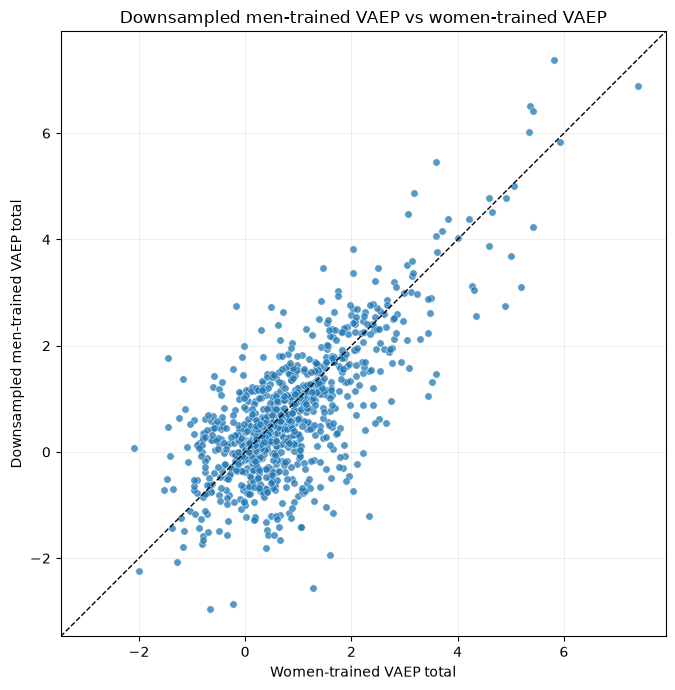

In [9]:
fig, axis = plt.subplots(figsize=(7, 7))

axis.scatter(
    player_vaep_comparison["women_vaep"],
    player_vaep_comparison["men_downsampled_vaep"],
    alpha=0.75,
    s=28,
    edgecolors="white",
    linewidths=0.4,
)
axis_min = min(player_vaep_comparison["women_vaep"].min(), player_vaep_comparison["men_downsampled_vaep"].min())
axis_max = max(player_vaep_comparison["women_vaep"].max(), player_vaep_comparison["men_downsampled_vaep"].max())
padding = (axis_max - axis_min) * 0.05 if axis_max > axis_min else 0.01
axis_min -= padding
axis_max += padding
axis.plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--", color="black", linewidth=1)
axis.set_xlim(axis_min, axis_max)
axis.set_ylim(axis_min, axis_max)
axis.set_aspect("equal", adjustable="box")
axis.set_xlabel("Women-trained VAEP total")
axis.set_ylabel("Downsampled men-trained VAEP total")
axis.set_title("Downsampled men-trained VAEP vs women-trained VAEP")
axis.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 10. 按 position bucket 分析 VAEP 排名差异

这里把 test-set 球员按主要位置分组，看男足模型和女足模型在不同位置上的排名差异是否不同。

In [10]:
player_vaep_by_position = player_vaep_comparison.copy()
player_vaep_by_position["primary_position"] = player_vaep_by_position["player_id_key"].map(primary_position_from_key)
player_vaep_by_position["position_bucket"] = player_vaep_by_position["primary_position"].map(bucket_position)

player_vaep_by_position["bucket_men_rank"] = player_vaep_by_position.groupby("position_bucket")[
    "men_downsampled_vaep"
].rank(ascending=False, method="min")
player_vaep_by_position["bucket_women_rank"] = player_vaep_by_position.groupby("position_bucket")[
    "women_vaep"
].rank(ascending=False, method="min")
player_vaep_by_position["bucket_rank_delta"] = (
    player_vaep_by_position["bucket_men_rank"] - player_vaep_by_position["bucket_women_rank"]
)
player_vaep_by_position["abs_bucket_rank_delta"] = player_vaep_by_position["bucket_rank_delta"].abs()

position_rows = []
for position_bucket, bucket_players in player_vaep_by_position.groupby("position_bucket"):
    spearman = spearman_if_available(
        bucket_players["men_downsampled_vaep"],
        bucket_players["women_vaep"],
        min_observations=MIN_PLAYERS_PER_POSITION_BUCKET,
    )

    position_rows.append(
        {
            "position_bucket": position_bucket,
            "players": len(bucket_players),
            "actions": int(bucket_players["action_count"].sum()),
            "spearman_men_vs_women_vaep": spearman,
            "aggregate_vaep_delta": bucket_players["vaep_delta"].sum(),
            "mean_vaep_delta": bucket_players["vaep_delta"].mean(),
            "mean_abs_vaep_delta": bucket_players["abs_vaep_delta"].mean(),
            "mean_bucket_rank_delta": bucket_players["bucket_rank_delta"].mean(),
            "median_abs_bucket_rank_delta": bucket_players["abs_bucket_rank_delta"].median(),
            "max_abs_bucket_rank_delta": bucket_players["abs_bucket_rank_delta"].max(),
        }
    )

position_bucket_vaep_summary = (
    pd.DataFrame(position_rows)
    .sort_values(["players", "actions"], ascending=False)
    .reset_index(drop=True)
)

print("Position-bucket VAEP summary:")
display(position_bucket_vaep_summary.round(4))

print()
print("Players with largest within-bucket VAEP rank changes:")
display(
    player_vaep_by_position.sort_values("abs_bucket_rank_delta", ascending=False)[
        [
            "player_id",
            "primary_position",
            "position_bucket",
            "action_count",
            "men_downsampled_vaep",
            "women_vaep",
            "vaep_delta",
            "bucket_men_rank",
            "bucket_women_rank",
            "bucket_rank_delta",
        ]
    ]
    .head(25)
    .round(4)
)

Position-bucket VAEP summary:


,position_bucket,players,actions,spearman_men_vs_women_vaep,aggregate_vaep_delta,mean_vaep_delta,mean_abs_vaep_delta,mean_bucket_rank_delta,median_abs_bucket_rank_delta,max_abs_bucket_rank_delta
0,Fullback / Wing Back,212,95480,0.5576,-21.9175,-0.1034,0.6468,0.0,24.5,162.0
1,Center Back,205,106130,0.2793,-30.0926,-0.1468,0.7123,0.0,34.0,193.0
2,Defensive Midfield,159,66482,0.6795,-29.2710,-0.1841,0.5086,0.0,17.0,124.0
3,Wide Midfielder / Winger,139,46017,0.8091,4.0229,0.0289,0.5186,0.0,9.0,103.0
4,Forward,130,36948,0.7877,-6.0624,-0.0466,0.6137,0.0,10.0,102.0
5,Central Midfield,75,30364,0.6380,-21.8817,-0.2918,0.6497,0.0,7.0,58.0
6,Attacking Midfield,55,21537,0.6755,-11.1562,-0.2028,0.6163,0.0,6.0,36.0



Players with largest within-bucket VAEP rank changes:


,player_id,primary_position,position_bucket,action_count,men_downsampled_vaep,women_vaep,vaep_delta,bucket_men_rank,bucket_women_rank,bucket_rank_delta
827,53183.0,Right Center Back,Center Back,235,1.7602,-1.4591,3.2193,12.0,205.0,-193.0
1129,309392.0,Right Center Back,Center Back,790,-1.9426,1.6051,-3.5478,202.0,15.0,187.0
714,49950.0,Right Center Back,Center Back,606,1.3790,-1.1735,2.5525,19.0,202.0,-183.0
146,10208.0,Left Center Back,Center Back,1154,-0.7370,2.0273,-2.7643,185.0,8.0,177.0
941,128665.0,Right Center Back,Center Back,1175,-2.5687,1.2831,-3.8518,203.0,30.0,173.0
1333,409155.0,Right Back,Fullback / Wing Back,634,-1.0388,1.5154,-2.5541,199.0,37.0,162.0
2,4636.0,Left Center Back,Center Back,276,1.2292,-0.6108,1.8400,26.0,187.0,-161.0
402,32074.0,Right Center Back,Center Back,450,-0.4903,1.6221,-2.1125,172.0,14.0,158.0
334,25687.0,Center Back,Center Back,1066,-1.4044,1.0534,-2.4578,198.0,40.0,158.0
598,46874.0,Left Center Back,Center Back,794,1.3177,-0.4398,1.7576,23.0,181.0,-158.0


## 10.1 Position-bucket visualization

这些图分别看：

- 每个位置 bucket 内，男足 VAEP 和女足 VAEP 的排名相关性。
- 每个位置 bucket 内，player-level VAEP delta 的分布，而不是只看平均值。
- 每个位置 bucket 内，男足 VAEP 排名相对女足 VAEP 排名的移动分布。

右图的横轴是 `player_vaep_delta = men_downsampled_vaep - women_vaep`。每一行是一类位置的球员分布；偏蓝表示该位置 bucket 的 mean delta 更负，偏红表示 mean delta 更正。黑点标出该位置 bucket 的 mean delta。

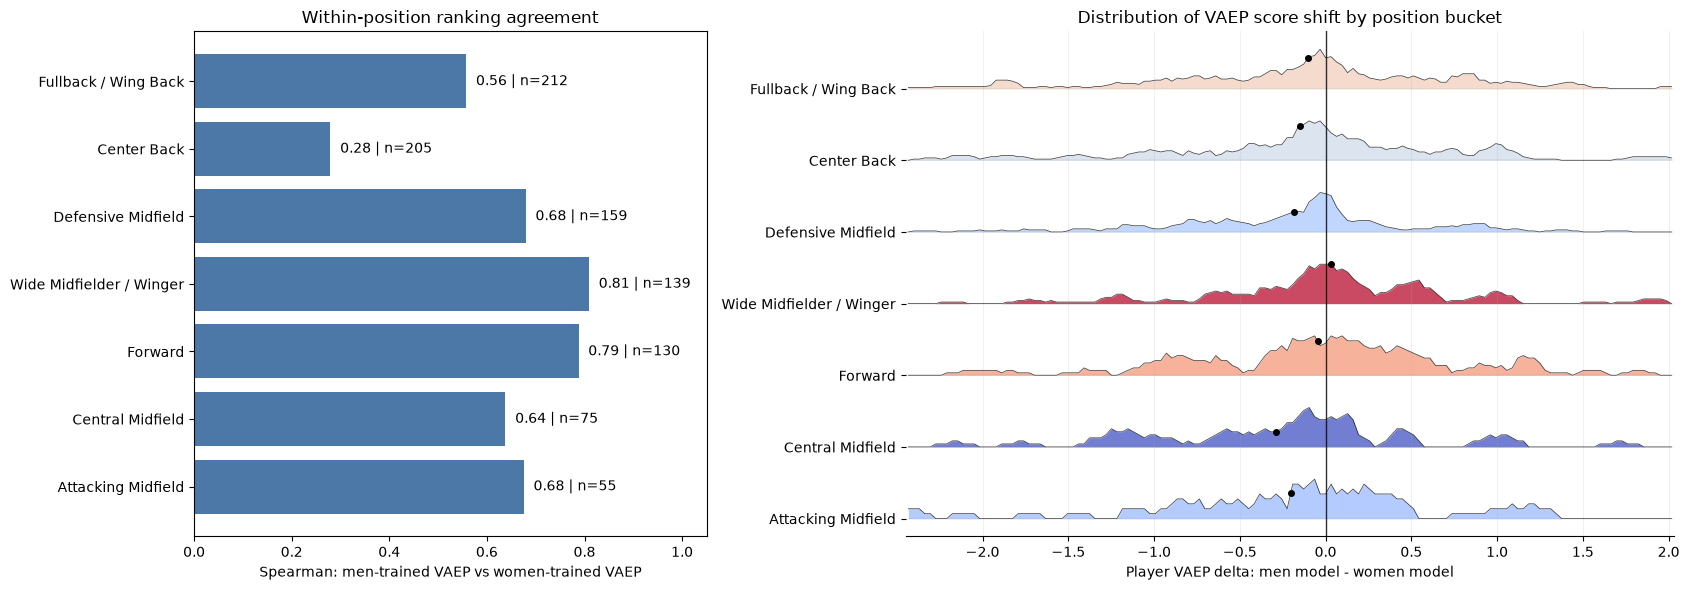

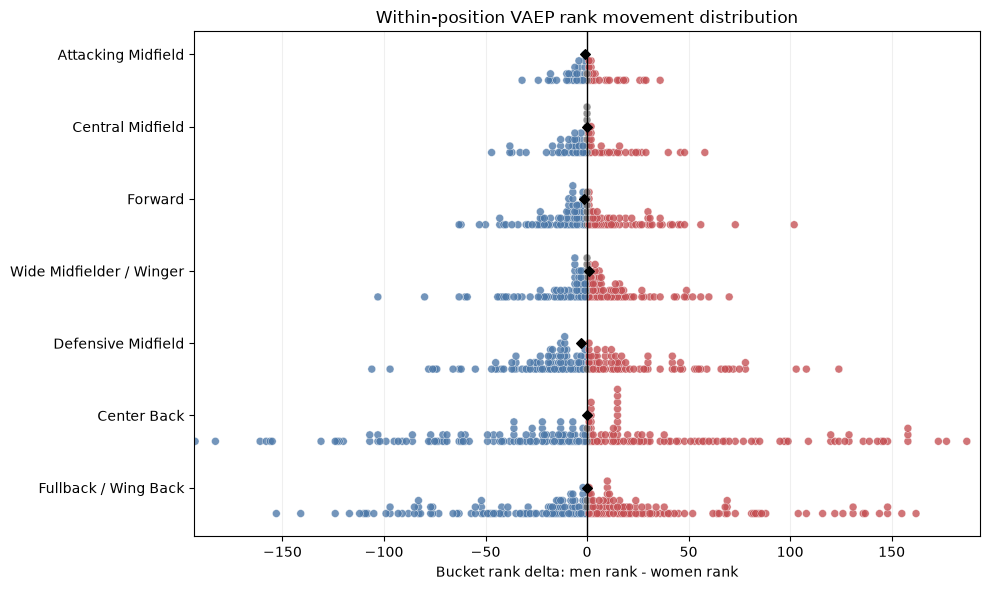

Note: position distributions are smoothed histograms, clipped to the 2%-98% player-delta range for readability. Each ridge is normalized to height 0.55, so shapes are comparable but player counts are shown in the summary table.


In [11]:
plot_position_summary = position_bucket_vaep_summary.sort_values("players", ascending=True)
position_bucket_order = plot_position_summary["position_bucket"].tolist()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, max(6, 0.45 * len(position_bucket_order) + 2)),
    gridspec_kw={"width_ratios": [0.9, 1.35]},
)

axes[0].barh(
    plot_position_summary["position_bucket"],
    plot_position_summary["spearman_men_vs_women_vaep"],
    color="#4C78A8",
)
axes[0].set_xlim(0, 1.05)
axes[0].set_xlabel("Spearman: men-trained VAEP vs women-trained VAEP")
axes[0].set_title("Within-position ranking agreement")
for y_index, row in enumerate(plot_position_summary.itertuples(index=False)):
    label = "n=" + str(row.players)
    if pd.notna(row.spearman_men_vs_women_vaep):
        label = f"{row.spearman_men_vs_women_vaep:.2f} | " + label
    axes[0].text(
        0.02 if pd.isna(row.spearman_men_vs_women_vaep) else min(row.spearman_men_vs_women_vaep + 0.02, 0.98),
        y_index,
        label,
        va="center",
    )

POSITION_DISTRIBUTION_BINS = 140
POSITION_DISTRIBUTION_QUANTILES = (0.02, 0.98)
POSITION_SMOOTHING_WINDOW = 5
POSITION_RIDGE_HEIGHT = 0.55
POSITION_ROW_SPACING = 1.0

position_distribution_rows = player_vaep_by_position[
    player_vaep_by_position["position_bucket"].isin(position_bucket_order)
].copy()

x_min, x_max = position_distribution_rows["vaep_delta"].quantile(POSITION_DISTRIBUTION_QUANTILES)
if np.isclose(x_min, x_max):
    x_min -= 0.001
    x_max += 0.001

x_padding = 0.08 * (x_max - x_min)
x_min -= x_padding
x_max += x_padding

bin_edges = np.linspace(x_min, x_max, POSITION_DISTRIBUTION_BINS + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
smoothing_kernel = np.ones(POSITION_SMOOTHING_WINDOW) / POSITION_SMOOTHING_WINDOW

cmap = plt.colormaps["coolwarm"]
color_norm = plt.Normalize(
    plot_position_summary["mean_vaep_delta"].min(),
    plot_position_summary["mean_vaep_delta"].max(),
)
y_positions = np.arange(len(position_bucket_order)) * POSITION_ROW_SPACING

for y_position, position_bucket in zip(y_positions, position_bucket_order):
    values = position_distribution_rows.loc[
        position_distribution_rows["position_bucket"] == position_bucket,
        "vaep_delta",
    ].dropna().to_numpy()

    histogram, _ = np.histogram(values, bins=bin_edges, density=True)
    smoothed_density = np.convolve(histogram, smoothing_kernel, mode="same")
    if smoothed_density.max() > 0:
        smoothed_density = smoothed_density / smoothed_density.max() * POSITION_RIDGE_HEIGHT

    summary_row = plot_position_summary[plot_position_summary["position_bucket"] == position_bucket].iloc[0]
    ridge_color = cmap(color_norm(summary_row["mean_vaep_delta"]))

    axes[1].fill_between(
        bin_centers,
        y_position,
        y_position + smoothed_density,
        color=ridge_color,
        alpha=0.72,
        linewidth=0,
    )
    axes[1].plot(
        bin_centers,
        y_position + smoothed_density,
        color="black",
        linewidth=0.55,
        alpha=0.75,
    )
    axes[1].hlines(y_position, x_min, x_max, color="gray", linewidth=0.35, alpha=0.35)

    mean_delta = values.mean()
    if x_min <= mean_delta <= x_max:
        mean_height = np.interp(mean_delta, bin_centers, smoothed_density)
        axes[1].scatter(mean_delta, y_position + mean_height, color="black", s=16, zorder=4)

axes[1].axvline(0, color="black", linewidth=1.0, alpha=0.8)
axes[1].set_yticks(y_positions)
axes[1].set_yticklabels(position_bucket_order)
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_positions[0] - 0.25, y_positions[-1] + POSITION_RIDGE_HEIGHT + 0.25)
axes[1].set_xlabel("Player VAEP delta: men model - women model")
axes[1].set_title("Distribution of VAEP score shift by position bucket")
axes[1].grid(axis="x", alpha=0.18)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

ordered_buckets = position_bucket_vaep_summary.sort_values("players", ascending=False)["position_bucket"].tolist()
rank_distribution_rows = player_vaep_by_position.dropna(subset=["bucket_rank_delta"]).copy()
RANK_STACK_HEIGHT = 0.72
RANK_STACK_POINT_STEP = 0.09
RANK_STACK_BOTTOM = -RANK_STACK_HEIGHT / 2

fig, axis = plt.subplots(figsize=(10, max(6, 0.55 * len(ordered_buckets) + 2)))
for y_index, position_bucket in enumerate(ordered_buckets):
    bucket_rank_values = rank_distribution_rows.loc[
        rank_distribution_rows["position_bucket"].eq(position_bucket),
        "bucket_rank_delta",
    ].to_numpy()
    if len(bucket_rank_values) == 0:
        continue

    y_offsets = np.zeros_like(bucket_rank_values, dtype=float)
    unique_rank_values, rank_group_ids = np.unique(bucket_rank_values, return_inverse=True)
    max_stack_size = max(np.bincount(rank_group_ids))
    stack_step = min(
        RANK_STACK_POINT_STEP,
        RANK_STACK_HEIGHT / max(max_stack_size - 1, 1),
    )
    for rank_group_id in range(len(unique_rank_values)):
        matching_points = np.flatnonzero(rank_group_ids == rank_group_id)
        y_offsets[matching_points] = RANK_STACK_BOTTOM + np.arange(len(matching_points)) * stack_step

    rank_colors = np.where(
        bucket_rank_values > 0,
        "#C44E52",
        np.where(bucket_rank_values < 0, "#4C78A8", "#777777"),
    )
    axis.scatter(
        bucket_rank_values,
        y_index + y_offsets,
        color=rank_colors,
        alpha=0.78,
        s=32,
        edgecolors="white",
        linewidths=0.35,
    )
    axis.scatter(
        np.median(bucket_rank_values),
        y_index,
        color="black",
        marker="D",
        s=24,
        zorder=4,
    )

rank_limit = rank_distribution_rows["bucket_rank_delta"].abs().max()
if pd.isna(rank_limit) or rank_limit == 0:
    rank_limit = 1
axis.axvline(0, color="black", linewidth=1)
axis.set_xlim(-rank_limit - 0.5, rank_limit + 0.5)
axis.set_yticks(np.arange(len(ordered_buckets)))
axis.set_yticklabels(ordered_buckets)
axis.set_xlabel("Bucket rank delta: men rank - women rank")
axis.set_title("Within-position VAEP rank movement distribution")
axis.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

print(
    "Note: position distributions are smoothed histograms, clipped to the "
    f"{POSITION_DISTRIBUTION_QUANTILES[0]:.0%}-{POSITION_DISTRIBUTION_QUANTILES[1]:.0%} player-delta range for readability. "
    f"Each ridge is normalized to height {POSITION_RIDGE_HEIGHT}, so shapes are comparable but player counts are shown in the summary table."
)

## 11. Action-type mechanism：哪些动作被男足模型和女足模型估值不同？

VAEP 的优势是能看不同 action type 的差异。这里先按 action type 汇总 action-level VAEP delta，然后不只看 mean，而是把每类动作的 delta distribution 画出来。

图里的横轴是 `vaep_delta = men_downsampled_vaep - women_vaep`。正值表示男足模型给该类女足 test actions 的 VAEP 更高；负值表示女足模型更高。

2D ridgeline 图的读法：每一行是一种 action type 的 delta 分布；隆起越高，说明该 delta 附近的 actions 越多。每一行的颜色表示该 action type 的 mean delta：偏蓝表示女足模型平均给分更高，偏红表示男足模型平均给分更高。黑点标出该类动作的 mean delta。

Action types with at least 500 test actions:


,type_name,actions,aggregate_vaep_delta,mean_vaep_delta,median_vaep_delta,delta_std,mean_men_vaep,mean_women_vaep
7,freekick_crossed,1854,-9.421724,-0.005082,-0.002123,0.029510,0.010090,0.015172
1,clearance,11250,-38.513489,-0.003423,0.000064,0.117699,-0.000913,0.002510
12,shot,5734,-15.506318,-0.002704,-0.000890,0.138425,0.042594,0.045298
10,interception,4939,-11.355744,-0.002299,0.000516,0.061824,-0.002037,0.000262
0,bad_touch,8053,-16.553023,-0.002056,0.000354,0.056128,-0.010380,-0.008324
15,tackle,9424,-19.089094,-0.002026,0.000159,0.083161,0.001617,0.003643
5,dribble,169402,-24.289008,-0.000143,-0.000067,0.038688,0.001964,0.002107
17,throw_in,12037,-0.132196,-0.000011,0.000323,0.023758,0.001155,0.001166
16,take_on,7333,-0.073006,-0.000010,0.000096,0.044338,-0.001374,-0.001364
11,pass,170861,4.462549,0.000026,0.000013,0.028219,0.000786,0.000760


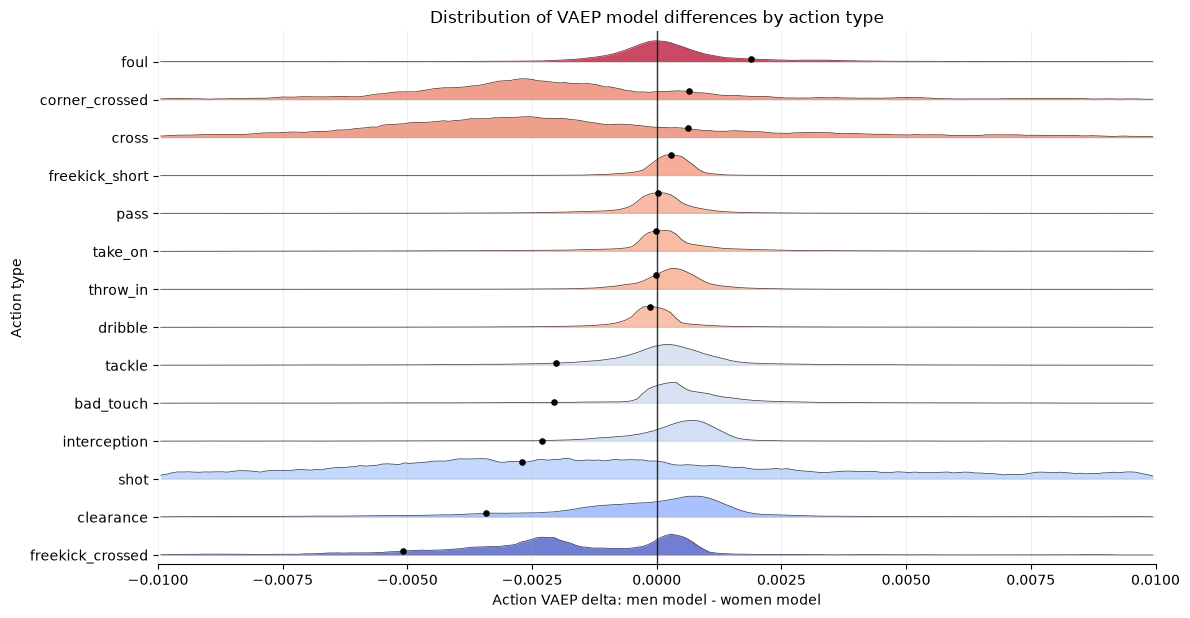

Note: distributions are smoothed histograms shown within [-0.01, +0.01] for readability. Each ridge is normalized to height 0.55, so shapes are comparable but absolute frequencies are shown in the table.


In [12]:
non_goalkeeper_predictions = vaep_predictions[~vaep_predictions["player_id_key"].map(is_goalkeeper_key)].copy()

action_type_vaep_summary = (
    non_goalkeeper_predictions
    .groupby("type_name")
    .agg(
        actions=("vaep_delta", "size"),
        aggregate_vaep_delta=("vaep_delta", "sum"),
        mean_vaep_delta=("vaep_delta", "mean"),
        median_vaep_delta=("vaep_delta", "median"),
        delta_std=("vaep_delta", "std"),
        mean_men_vaep=("men_downsampled_vaep", "mean"),
        mean_women_vaep=("women_vaep", "mean"),
    )
    .reset_index()
)

action_type_vaep_summary = action_type_vaep_summary[
    action_type_vaep_summary["actions"] >= MIN_ACTIONS_PER_ACTION_TYPE
].sort_values("mean_vaep_delta")

print(f"Action types with at least {MIN_ACTIONS_PER_ACTION_TYPE:,} test actions:")
display(action_type_vaep_summary.round(6))

selected_action_types = action_type_vaep_summary["type_name"].tolist()
distribution_rows = non_goalkeeper_predictions[
    non_goalkeeper_predictions["type_name"].isin(selected_action_types)
].copy()

DISTRIBUTION_BINS = 180
SMOOTHING_WINDOW = 7
RIDGE_HEIGHT = 0.55
ROW_SPACING = 1.0
PLOT_DELTA_LIMIT = 0.01

x_min, x_max = -PLOT_DELTA_LIMIT, PLOT_DELTA_LIMIT

bin_edges = np.linspace(x_min, x_max, DISTRIBUTION_BINS + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
smoothing_kernel = np.ones(SMOOTHING_WINDOW) / SMOOTHING_WINDOW

fig_height = max(6, 0.32 * len(selected_action_types) + 1.8)
fig, axis = plt.subplots(figsize=(12, fig_height))

cmap = plt.colormaps["coolwarm"]
color_norm = plt.Normalize(
    action_type_vaep_summary["mean_vaep_delta"].min(),
    action_type_vaep_summary["mean_vaep_delta"].max(),
)

y_positions = np.arange(len(selected_action_types)) * ROW_SPACING

for y_position, action_type in zip(y_positions, selected_action_types):
    values = distribution_rows.loc[
        distribution_rows["type_name"] == action_type,
        "vaep_delta",
    ].dropna().to_numpy()

    histogram, _ = np.histogram(values, bins=bin_edges, density=True)
    smoothed_density = np.convolve(histogram, smoothing_kernel, mode="same")
    if smoothed_density.max() > 0:
        smoothed_density = smoothed_density / smoothed_density.max() * RIDGE_HEIGHT

    summary_row = action_type_vaep_summary[action_type_vaep_summary["type_name"] == action_type].iloc[0]
    ridge_color = cmap(color_norm(summary_row["mean_vaep_delta"]))

    axis.fill_between(
        bin_centers,
        y_position,
        y_position + smoothed_density,
        color=ridge_color,
        alpha=0.72,
        linewidth=0,
    )
    axis.plot(
        bin_centers,
        y_position + smoothed_density,
        color="black",
        linewidth=0.55,
        alpha=0.75,
    )
    axis.hlines(y_position, x_min, x_max, color="gray", linewidth=0.35, alpha=0.35)

    mean_delta = values.mean()
    if x_min <= mean_delta <= x_max:
        mean_height = np.interp(mean_delta, bin_centers, smoothed_density)
        axis.scatter(mean_delta, y_position + mean_height, color="black", s=14, zorder=4)

axis.axvline(0, color="black", linewidth=1.0, alpha=0.8)
axis.set_yticks(y_positions)
axis.set_yticklabels(selected_action_types)
axis.set_xlim(x_min, x_max)
axis.set_ylim(y_positions[0] - 0.25, y_positions[-1] + RIDGE_HEIGHT + 0.25)
axis.set_xlabel("Action VAEP delta: men model - women model")
axis.set_ylabel("Action type")
axis.set_title("Distribution of VAEP model differences by action type")
axis.grid(axis="x", alpha=0.18)
axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)
axis.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

print(
    "Note: distributions are smoothed histograms shown within "
    f"[-{PLOT_DELTA_LIMIT:.2f}, +{PLOT_DELTA_LIMIT:.2f}] for readability. "
    f"Each ridge is normalized to height {RIDGE_HEIGHT}, so shapes are comparable but absolute frequencies are shown in the table."
)

## 12. Read-out

这个 notebook 最后应该回答：

1. 男足训练的 VAEP 模型和女足训练的 VAEP 模型，在同一批女足 test actions 上给出的球员排名有多一致？
2. 差异是否集中在某些 position bucket？
3. 差异是否集中在某些 action type？

如果 VAEP 比 xG/xT 显示更低 Spearman 或更明显的位置/action-type 差异，说明更细粒度的 action-value model 捕捉到了 position-only 或 shot-only metric 看不到的迁移差异。